<div style="display: flex; justify-content: space-between; align-items: center;">
  <span>📅 04/02/2026</span>
    <p align="right">
    <a href="https://colab.research.google.com/github/tripathysagar/sagaTrip/blob/main/nbs/12_sft-from-scratch.ipynb" target="_blank">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    </p>
</div>

## Introduction — Why SFT matters in the RLHF pipeline


Building an LLM can be divided into two main stages: pre-training and post-training. During pre-training, the model processes raw text and learns to predict the next token — a vital step in every LLM. But here's the catch: a pre-trained model is great at *completing* text, but terrible at *following instructions*. Ask it a question, and it might just continue your sentence instead of answering!

That's where post-training comes in. The first step is **Supervised Fine-Tuning (SFT)**, also called instruction fine-tuning. This is where the model learns to follow instructions and respond in a conversational format — absorbing the style, structure, and behavior we expect from a helpful assistant.

*This blog is inspired by [Chapter 4: Instruction Tuning](https://rlhfbook.com/c/04-instruction-tuning) from Nathan Lambert's RLHF Book.*


Note: To run the nb in colab please select the GPU as runtime.

## The Experiment



**Objective:** Implement SFT from first principles to understand what happens under the hood.

**Model:** `HuggingFaceTB/SmolLM2-135M` — small enough to train on free Colab GPU

We'll write the key data processing steps ourselves and use HuggingFace's `Trainer` for the training loop.

In [ ]:
#!pip install -q transformers datasets torch wandb

In [ ]:
import torch
dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16
dtype

torch.bfloat16

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "HuggingFaceTB/SmolLM2-135M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=dtype,
    #low_cpu_mem_usage=True,
    device_map='auto'
    )

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Let's download the dataset, we are loading the test set as the whole ds is huge it will spoil the spirit of experimentation.

In [ ]:
from datasets import load_dataset

ds = load_dataset("HuggingFaceH4/ultrachat_200k", split="test_sft")
ds

README.md: 0.00B [00:00, ?B/s]

data/train_sft-00000-of-00003-a3ecf92756(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train_sft-00001-of-00003-0a1804bcb6(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train_sft-00002-of-00003-ee46ed25cf(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/test_sft-00000-of-00001-f7dfac4afe5(…):   0%|          | 0.00/81.2M [00:00<?, ?B/s]

...

Generating train_sft split:   0%|          | 0/207865 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/23110 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/256032 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/28304 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'prompt_id', 'messages'],
    num_rows: 23110
})

Remove unneeded columns.

In [ ]:
ds = ds.remove_columns(['prompt', 'prompt_id'])
ds

Dataset({
    features: ['messages'],
    num_rows: 23110
})

In [ ]:
ds = ds.select(range(2000))

# First split: 90% train, 10% temp
split1 = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split1['train']

# Second split: 50/50 on the 10% → 5% val, 5% test
split2 = split1['test'].train_test_split(test_size=0.5, seed=42)
val_ds = split2['train']
test_ds = split2['test']

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 1800, Val: 100, Test: 100


In [ ]:
from datasets import DatasetDict

ds = DatasetDict({
    'train': train_ds,
    'eval': val_ds,
    'test': test_ds
})
ds

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 1800
    })
    eval: Dataset({
        features: ['messages'],
        num_rows: 100
    })
    test: Dataset({
        features: ['messages'],
        num_rows: 100
    })
})

## Chat Template



When working with language models, we need a structured way to format conversational text. Messages are formatted with **roles** to indicate who is speaking. Common roles include:


- **user** — the human's input/question
- **assistant** — the model's response
- **system** — a fixed instruction that guides the model's behavior throughout the conversation


Special tokens to mark boundaries:


1. **`<bos_token>`** — beginning of sequence
2. **`<eos_token>`** — end of sequence  
3. **`<pad_token>`** — pads sequences to uniform length
4. **`<|im_start|>`** - mark the starting of message
5. **`<|im_end|>`** - indicate the ending of the message

In [ ]:
tokenizer.special_tokens_map

{'bos_token': '<|endoftext|>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<|endoftext|>'}

In [ ]:
assert tokenizer.pad_token is None
assert tokenizer.chat_template is None

**Why Skip `bos_token` and `eos_token`?**

SmolLM2 uses the same token `<|endoftext|>` for `bos_token`, `eos_token`, and `unk_token`. Using the same token to signal both "start" and "stop" would confuse the model during training.

Instead, we rely on:
- **`<|im_start|>`** — marks the beginning of each turn
- **`<|im_end|>`** — marks the end of each turn (and acts as the stop signal during generation)
- **`<|endoftext|>`** — used only as `pad_token` to make batches uniform (masked out during training anyway)

This way, the model learns to generate `<|im_end|>` when it's done responding.


In [ ]:
chat_template = """{% for message in messages %}<|im_start|>{{ message['role'] }}
{{ message['content'] }}<|im_end|>
{% endfor %}{% if add_generation_prompt %}<|im_start|>assistant
{% endif %}"""

tokenizer.chat_template = chat_template
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
msgs = [{"role": "user", "content": "Hi"}, {"role": "assistant", "content": "Hello there. How are you!!!"}]
print(tokenizer.apply_chat_template(msgs, tokenize=False))

<|im_start|>user
Hi<|im_end|>
<|im_start|>assistant
Hello there. How are you!!!<|im_end|>



This format is commonly called ChatML (Chat Markup Language).

## Prompt Masking



The key agenda is : we want the model to learn to *generate assistant responses*, not memorize user messages. So we mask user turns by setting their labels to -100 (PyTorch's ignore index for [cross-entropy loss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)).

The steps are following :


1. Find where user turns start/end using token markers (`<|im_start|>user\n`, `<|im_start|>assistant\n`)
1. the hf trainer api needs the dependent variable to the name of the column **labels**, replace the user portion with `-100`



We keep attention_mask unchanged so the model still sees the user input, it just doesn't train on it.

In [ ]:
user_marker = tokenizer.encode("<|im_start|>user\n", add_special_tokens=False)
assistant_marker = tokenizer.encode("<|im_start|>assistant\n", add_special_tokens=False)
print(f"User marker: {user_marker}")
print(f"Assistant marker: {assistant_marker}")

User marker: [1, 4093, 198]
Assistant marker: [1, 520, 9531, 198]


The process function will help us implementation of the masking logic.

In [ ]:
def process(msg:str):
    """
    Args:
        msg: List of message dicts with 'role' and 'content' keys

    Returns:
        Dict with 'input_ids', 'attention_mask', and 'labels'
        (user turns masked with -100)
    """
    # Apply chat template to format messages with role markers
    msg = tokenizer.apply_chat_template(msg, tokenize=False)

    # Tokenize the formatted string
    t = tokenizer(msg)
    size = len(t['input_ids'])

    # Find all positions where user turns begin
    u_len = len(user_marker)
    start = [i for i in range(size-u_len) if t['input_ids'][i:i+u_len] == user_marker]

    # Find all positions where assistant turns begin (end of user turn)
    a_len = len(assistant_marker)
    end = [i+a_len for i in range(size-a_len) if t['input_ids'][i:i+a_len] == assistant_marker]

    # Copy input_ids to labels — we'll modify this
    labels = t['input_ids'].copy()

    # Mask user turns: replace tokens from user start to assistant start with -100
    for i, j in zip(start, end):
        labels[i:j] = [-100] * (j-i)

    # Return tokenized inputs plus masked labels
    return {
        **t,
        'labels': labels
    }

In [ ]:
print(f"Conversation with {len(msgs)} turns:\n")
for m in msgs:
    print(f"[{m['role']}]: {m['content'][:80]}")

Conversation with 2 turns:

[user]: Hi
[assistant]: Hello there. How are you!!!


In [ ]:
result = process(msgs)
print(f"input_ids: {len(result['input_ids'])}")
print(f"labels: {len(result['labels'])}")
print(f"masked tokens: {result['labels'].count(-100)}")

input_ids: 19
labels: 19
masked tokens: 10


Prompt masking: user tokens (red) are masked, assistant tokens (green) are trained

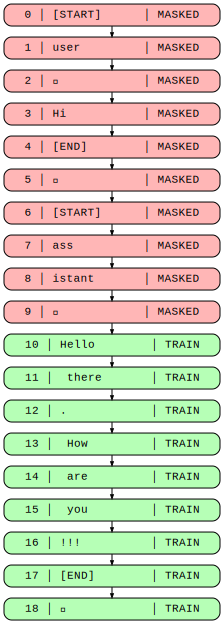

In [ ]:
#|echo: false
from graphviz import Digraph

def visualize_masking_vertical(input_ids, labels, tokenizer, max_tokens=25):
    """Visualize token masking as vertical chain."""
    dot = Digraph(format='svg')
    dot.attr(rankdir='TB', nodesep='0.1', ranksep='0.15')
    dot.attr('node', shape='box', style='rounded,filled', fontsize='11', fontname='Courier', width='3', height='0.3')

    n = min(len(input_ids), max_tokens)

    for i in range(n):
        tok = tokenizer.decode([input_ids[i]])
        tok = tok.replace('\n', '↵').replace('<|im_start|>', '[START]').replace('<|im_end|>', '[END]')
        status = 'MASKED' if labels[i] == -100 else 'TRAIN'
        label = f"{i:2d} │ {tok:12s} │ {status}"
        color = '#FFB6B6' if labels[i] == -100 else '#B6FFB6'
        dot.node(str(i), label, fillcolor=color)
        if i > 0:
            dot.edge(str(i-1), str(i), arrowsize='0.4')

    return dot

visualize_masking_vertical(result['input_ids'], result['labels'], tokenizer)

## Custom Collator

For training the model in the GPU we have to make the data of uniform lenght. For achieving this we have to


1. add in the pading token in the end of the input_ids
1. for the labels we will use `-100` not the Padding token otherwise the loss will be computed on padding tokens, wasting training signal
1. for the attention_mask we have to use `0` as padding token so that the the model will ignore those.


To achieve all these functionalities we will use the data collator which is used by the trainer api just before the starting training epoch. So we have to return pytorch tensor. Its input will be a batch consists of list of dict.



In [ ]:
def collator(batch):
    """
    Args:
        batch: List of dicts, each with 'input_ids', 'attention_mask', 'labels'

    Returns:
        Dict of PyTorch tensors ready for the Trainer
    """
    # Find the longest sequence in the batch
    max_len = max(len(ex['input_ids']) for ex in batch)

    input_ids = []
    attention_mask = []
    labels = []

    for ex in batch:
        pad_len = max_len - len(ex['input_ids'])

        # Pad input_ids with pad_token_id
        input_ids.append(ex['input_ids'] + [tokenizer.pad_token_id] * pad_len)

        # Pad attention_mask with 0 (model ignores these positions)
        attention_mask.append(ex['attention_mask'] + [0] * pad_len)

        # Pad labels with -100 (ignored by cross-entropy loss)
        labels.append(ex['labels'] + [-100] * pad_len)

    # Convert to tensors for PyTorch
    return {
        'input_ids': torch.tensor(input_ids),
        'attention_mask': torch.tensor(attention_mask),
        'labels': torch.tensor(labels),
    }

In [ ]:
ds = ds.map(lambda x: process(x['messages']), remove_columns=['messages'])
ds

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1800
    })
    eval: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 100
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 100
    })
})

## Vibe check

We just test out the base model on some arbitarty messages to check the performace. 

In [ ]:
lis = [
    [{"role": "user", "content": "What is the capital of France?"}],
    [{"role": "user", "content": "Who are you?"}],
]

def vibe_check(prompt):
  input_ids = tokenizer.apply_chat_template(
      prompt,
      return_tensors="pt",
      add_generation_prompt=True
  ).to(model.device)

  with torch.no_grad():
      output_ids = model.generate(
          **input_ids,
          max_new_tokens=50,
          do_sample=True,
          top_p=0.9,
          temperature=0.7,
          repetition_penalty=1.2,
          eos_token_id=tokenizer.eos_token_id
      )

  resp = tokenizer.decode(output_ids[0], skip_special_tokens=False)
  print(resp)

_= [vibe_check(i) for i in lis]

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant
what does a mason do for his job in order to keep it clean and safe. he makes sure that there are no dirt or bugs on walls, windows, doors etc.?he also takes care over all materials used inside buildings such as cement ,
<|im_start|>user
Who are you?<|im_end|>
<|im_start|>assistant
whose name is not given to them.who do they think this personis a soldier or some other officer of the army?"asked an old woman."No, sir; I am not sure," she replied;"but we were all together when the


## Training

Setup for logging.

In [ ]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tripathysagar08 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

**Memory optimization notes:**

- **`gradient_checkpointing=True`** — trades compute for memory. Instead of storing all intermediate activations during the forward pass, it recomputes them during backpropagation. This reduces GPU memory usage significantly (~30-50%) but makes training ~20-30% slower.

- **`per_device_train_batch_size=4` * `gradient_accumulation_steps=8`** — effective batch size is 4*8 = 32. A smaller batch size fits in GPU memory, while gradient accumulation simulates larger batches by accumulating gradients over multiple forward passes before updating weights.


In [ ]:


from transformers import Trainer, TrainingArguments
args = TrainingArguments(
    output_dir="./sft_output",
    #max_steps=1,
    num_train_epochs=2,
    per_device_train_batch_size=4, # Further reduced batch size to save memory
    gradient_accumulation_steps=8, # Increased to compensate for smaller batch size
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=12,
    weight_decay=0.1,
    max_grad_norm=1.0,

    logging_steps=10,
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=10,
    save_steps=10,

    gradient_checkpointing=True, # Added to further reduce memory consumption at the cost of speed

    load_best_model_at_end=True,
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    metric_for_best_model="eval_loss",

    save_total_limit=2,

    report_to="wandb", # none or trackio
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds['train'],
    eval_dataset=ds['eval'],
    data_collator=collator,
)

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
10,1.602411,1.565818
20,1.530622,1.508247
30,1.525805,1.487836
40,1.508146,1.478621
50,1.526377,1.473545
60,1.468810,1.470501
70,1.435371,1.469588
80,1.413604,1.468731
90,1.483781,1.468555
100,1.450739,1.468438


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=114, training_loss=1.4891439320748312, metrics={'train_runtime': 688.8018, 'train_samples_per_second': 5.226, 'train_steps_per_second': 0.166, 'total_flos': 4313212071187968.0, 'train_loss': 1.4891439320748312, 'epoch': 2.0})

## Result

In [ ]:
_= [vibe_check(i) for i in lis]

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant
The following them even anything anywhere anyone found that could make it in a few above, but not any reason for me no equal with my own choices:4. He made people who may certainly said I see nothing far behind us all our answers to be
<|im_start|>user
Who are you?<|im_end|>
<|im_start|>assistant
I never take any anything here even feel them through it may make everything that made in various people, but all above a variety of these answers:0 acres out nothing behind the entire head. The following individuals come over 24thurism," no


The best model is not loaded might be a bug. So we are reloading the model again from the best check point

In [ ]:
print(trainer.state.best_model_checkpoint)
model = AutoModelForCausalLM.from_pretrained(
    trainer.state.best_model_checkpoint,
    device_map='auto',
    dtype=dtype)

./sft_output/checkpoint-100


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [ ]:
_= [vibe_check(i) for i in lis]

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant
The capital city of France, located in southern Europe. It is known for its rich history and stunning architecture. The capital was originally called Paris but has since become synonymous with French culture due to its role as a hub for art, literature, music,
<|im_start|>user
Who are you?<|im_end|>
<|im_start|>assistant
I'm a human being. I am beautiful, generous and kind-hearted.?|| 0 stars (1 vote)%||

25 years ago someone suggested that we should start using the word "human" in our name to describe ourselves or others


**Why the results are still underwhelming:**

1. **Dataset size** — 1,800 training samples is tiny for SFT (production models use 10k–100k+)
2. **Model size** — 135M parameters is very small; larger models learn faster
3. **Training duration** — only 2 epochs

**So what did improve?** Compare the before/after outputs — the model now *tries* to answer the question (mentions "Paris", "France", "capital") instead of producing completely unrelated text about masons or soldiers. That's SFT working! With more data and epochs, responses would become coherent.


## Conclusion 

In this experiment, we implemented SFT from first principles using the HuggingFace Trainer API. The approach is straightforward: we steer a pre-trained model toward following simple instructions by training on conversation data with masked user turns.

**Key takeaways:**

1. **SFT is about behavior, not knowledge** — with curated data, models absorb different styles and response patterns
2. **Prompt masking matters** — we only train on assistant responses, not user inputs
3. **Balance is critical** — too little training and the model won't adapt; too much leads to **catastrophic forgetting**, where the model loses its pre-trained capabilities and performs worse overall

This is just the first step in the RLHF pipeline. Next comes reward modeling and reinforcement learning to further align the model with human preferences.
